# Ajuste de limiar por custo de negócio

**Tema:** Preparação de Dados › Dados Desbalanceados

Este notebook mostra que mudar o limiar de decisão de um modelo **já
treinado** — sem reamostrar nada, sem retreinar — é, com frequência, a
alavanca mais barata para melhorar o resultado de negócio em problemas
desbalanceados. Terminamos formalizando a escolha do limiar a partir de uma
matriz de custo explícita.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix,
)

rng = np.random.default_rng(31)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Dataset e modelo (o mesmo tipo de cenário dos notebooks anteriores)

In [2]:
n = 8000
taxa_fraude = 0.04
n_fraude = int(n * taxa_fraude)
n_legitima = n - n_fraude

X_legitima = rng.multivariate_normal([90, 13], [[900, 0], [0, 16]], n_legitima)
X_fraude = rng.multivariate_normal([135, 8], [[900, 0], [0, 16]], n_fraude)
X = np.vstack([X_legitima, X_fraude])
y = np.concatenate([np.zeros(n_legitima), np.ones(n_fraude)])
ordem = rng.permutation(n)
X, y = X[ordem], y[ordem]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

modelo = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_treino, y_treino)
probs = modelo.predict_proba(X_teste)[:, 1]

print(f"proporção de fraude no teste: {y_teste.mean():.2%}")

proporção de fraude no teste: 4.00%


## 2. A curva precisão-recall como função do limiar

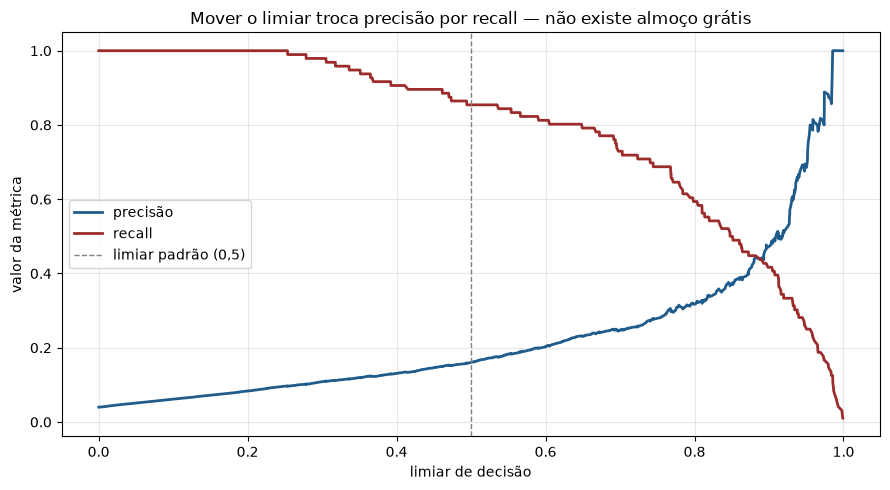

In [3]:
precisoes, recalls, limiares = precision_recall_curve(y_teste, probs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(limiares, precisoes[:-1], color=AZUL, lw=2, label="precisão")
ax.plot(limiares, recalls[:-1], color=VERMELHO, lw=2, label="recall")
ax.axvline(0.5, color="gray", ls="--", lw=1, label="limiar padrão (0,5)")
ax.set_xlabel("limiar de decisão"); ax.set_ylabel("valor da métrica")
ax.set_title("Mover o limiar troca precisão por recall — não existe almoço grátis")
ax.legend(); plt.tight_layout(); plt.show()

**Cada ponto do eixo x é uma escolha de negócio.** Limiares baixos capturam
mais fraudes reais (recall alto) às custas de mais alarmes falsos (precisão
baixa). Limiares altos fazem o oposto. O `predict()` padrão do `sklearn`
usa 0,5 — um valor conveniente, não uma verdade universal.

## 3. Formalizando com uma matriz de custo

Suponha: um falso negativo (fraude não detectada) custa, em média, R\$ 800
(o valor típico de uma fraude bem-sucedida). Um falso positivo (bloquear uma
transação legítima) custa R\$ 15 (o custo de suporte + risco de perder o
cliente). O limiar ótimo minimiza o custo total esperado.

custo total com limiar padrão (0,5)  : R$ 17,635.00
custo total com limiar ÓTIMO (0.301) : R$ 13,165.00

economia: R$ 4,470.00 (25.3%)


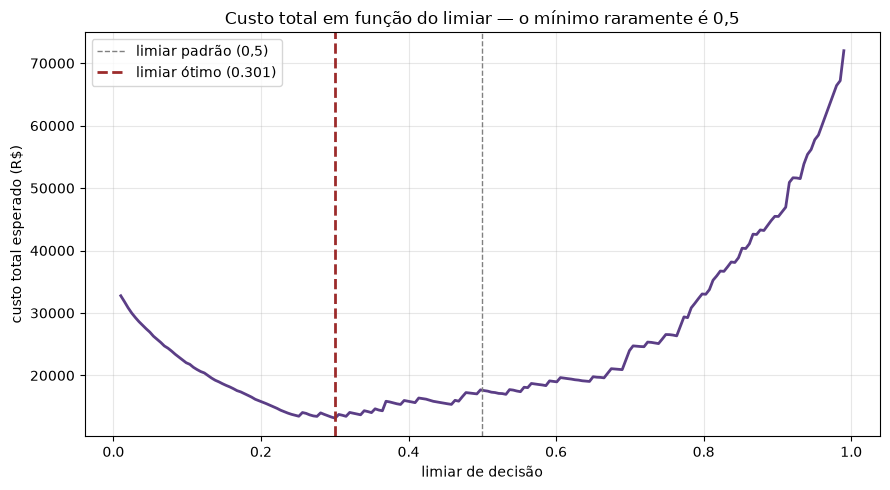

In [4]:
CUSTO_FALSO_NEGATIVO = 800
CUSTO_FALSO_POSITIVO = 15


def custo_total(y_real, probs, limiar):
    pred = (probs >= limiar).astype(int)
    matriz = confusion_matrix(y_real, pred)
    fp, fn = matriz[0, 1], matriz[1, 0]
    return fp * CUSTO_FALSO_POSITIVO + fn * CUSTO_FALSO_NEGATIVO


limiares_teste = np.linspace(0.01, 0.99, 200)
custos = [custo_total(y_teste, probs, t) for t in limiares_teste]

limiar_otimo = limiares_teste[np.argmin(custos)]
custo_no_otimo = min(custos)
custo_no_padrao = custo_total(y_teste, probs, 0.5)

print(f"custo total com limiar padrão (0,5)  : R$ {custo_no_padrao:,.2f}")
print(f"custo total com limiar ÓTIMO ({limiar_otimo:.3f}) : R$ {custo_no_otimo:,.2f}")
print(f"\neconomia: R$ {custo_no_padrao - custo_no_otimo:,.2f} "
      f"({(custo_no_padrao - custo_no_otimo) / custo_no_padrao:.1%})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(limiares_teste, custos, color=ROXO, lw=2)
ax.axvline(0.5, color="gray", ls="--", lw=1, label="limiar padrão (0,5)")
ax.axvline(limiar_otimo, color=VERMELHO, ls="--", lw=2,
          label=f"limiar ótimo ({limiar_otimo:.3f})")
ax.set_xlabel("limiar de decisão"); ax.set_ylabel("custo total esperado (R$)")
ax.set_title("Custo total em função do limiar — o mínimo raramente é 0,5")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Como a assimetria de custo desloca o limiar ótimo

Quanto mais caro o falso negativo em relação ao falso positivo, mais baixo
deve ser o limiar — o modelo passa a soar o alarme com menos evidência.

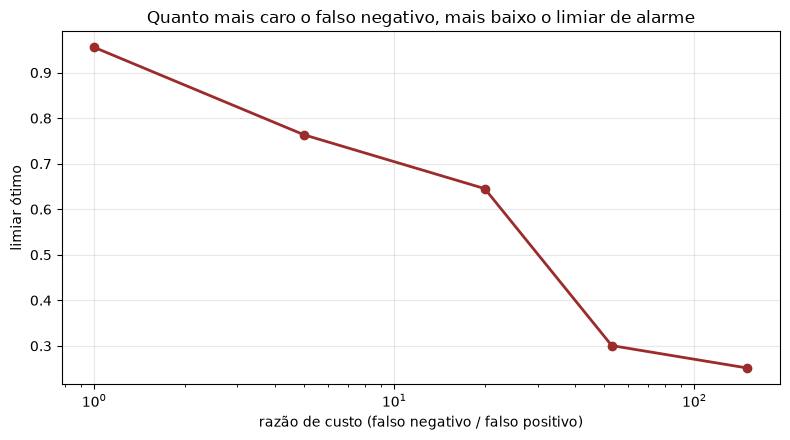

custo FN = 1x custo FP  ->  limiar ótimo = 0.956
custo FN = 5x custo FP  ->  limiar ótimo = 0.763
custo FN = 20x custo FP  ->  limiar ótimo = 0.645
custo FN = 53x custo FP  ->  limiar ótimo = 0.301
custo FN = 150x custo FP  ->  limiar ótimo = 0.251


In [5]:
razoes_de_custo = [1, 5, 20, 53, 150]  # FN/FP
resultado_limiares = []
for razao in razoes_de_custo:
    custo_fn_local = razao * CUSTO_FALSO_POSITIVO
    custos_local = [
        (confusion_matrix(y_teste, (probs >= t).astype(int))[0, 1] * CUSTO_FALSO_POSITIVO
         + confusion_matrix(y_teste, (probs >= t).astype(int))[1, 0] * custo_fn_local)
        for t in limiares_teste
    ]
    resultado_limiares.append(limiares_teste[np.argmin(custos_local)])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(razoes_de_custo, resultado_limiares, "o-", color=VERMELHO, lw=2)
ax.set_xscale("log")
ax.set_xlabel("razão de custo (falso negativo / falso positivo)")
ax.set_ylabel("limiar ótimo")
ax.set_title("Quanto mais caro o falso negativo, mais baixo o limiar de alarme")
plt.tight_layout(); plt.show()

for razao, lim in zip(razoes_de_custo, resultado_limiares):
    print(f"custo FN = {razao}x custo FP  ->  limiar ótimo = {lim:.3f}")

## 5. O que muda na matriz de confusão, concretamente

In [6]:
for nome, limiar in [("padrão", 0.5), ("ótimo para o custo do exercício", limiar_otimo)]:
    pred = (probs >= limiar).astype(int)
    matriz = confusion_matrix(y_teste, pred)
    print(f"\nlimiar {nome} ({limiar:.3f}):")
    print(f"  verdadeiros positivos (fraudes capturadas): {matriz[1,1]}")
    print(f"  falsos negativos (fraudes perdidas)        : {matriz[1,0]}")
    print(f"  falsos positivos (alarmes falsos)          : {matriz[0,1]}")
    print(f"  recall: {recall_score(y_teste, pred):.3f}   "
          f"precisão: {precision_score(y_teste, pred, zero_division=0):.3f}")


limiar padrão (0.500):
  verdadeiros positivos (fraudes capturadas): 82
  falsos negativos (fraudes perdidas)        : 14
  falsos positivos (alarmes falsos)          : 429
  recall: 0.854   precisão: 0.160

limiar ótimo para o custo do exercício (0.301):
  verdadeiros positivos (fraudes capturadas): 94
  falsos negativos (fraudes perdidas)        : 2
  falsos positivos (alarmes falsos)          : 771
  recall: 0.979   precisão: 0.109


## O que levar deste notebook

- Ajustar o limiar de decisão não exige retreinar nada — é a alavanca mais
  barata disponível depois de um modelo treinado.
- Toda escolha de limiar é uma troca entre precisão e recall — não existe
  limiar que maximize os dois ao mesmo tempo, exceto no caso degenerado de
  separação perfeita.
- O limiar ótimo depende do **custo real de cada erro**, uma decisão de
  negócio, não uma propriedade estatística do modelo.
- Quanto mais assimétrico o custo (falso negativo muito mais caro que falso
  positivo, como em fraude e diagnóstico médico), mais o limiar ótimo se
  afasta de 0,5.

→ Próximo: o notebook de **exercícios** do módulo — e o encerramento do tema
de Preparação de Dados.